# FERES Stroke Territory Analysis

This notebook walks through a FERES stroke territory analysis using the `mip` Python client.

It uses the newer notebook UX helpers throughout:

- `dm.tree()` / `catalog` HTML cards for discovery
- `dm.select(...)` to build the analysis set
- `result.to_frame()`, `result.highlights()`, and `result.plot()` for readable outputs


## Prerequisites

- **Data access:** `Stroke` data model version `3.7`, dataset `SSR`.
- **Connection:** Open this notebook from the MIP portal (or configure your local connection).
- **Docs:** `docs/quickstart.md`, `docs/how-to-choose.md`, `docs/troubleshooting.md`.


## 1. Load client, catalog, and SSR data

`Client.from_env()` uses your MIP platform connection. The catalog card and metadata tree help confirm the Stroke model before selecting variables.


In [ ]:
import mip
from mip.filters import F
from mip.preprocessing import (
    CategoricalColumnCreator,
    MissingValuesHandler,
    OutlierWinsorizer,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

print("Connecting to the MIP platform...", flush=True)
try:
    client = mip.Client.from_env()
except mip.MipConfigurationError as exc:
    raise RuntimeError(
        "Could not connect to the MIP platform. "
        "Open Jupyter from the MIP portal or see docs/troubleshooting.md."
    ) from exc

print("Loading catalog...", flush=True)
catalog = client.catalog()
display(catalog)

print("Loading Stroke 3.7 data model and SSR dataset...", flush=True)
try:
    dm = catalog.data_model("Stroke", version="3.7")
except LookupError:
    # Some deployments expose the combined label "Stroke 3.7".
    dm = catalog.data_model("Stroke 3.7")
ssr = dm.datasets["SSR"]

display(dm)
display(dm.tree())
display(ssr)
print("Ready.", flush=True)


## 2. Select variables

The analysis uses `clinical_sdr` (`Clinical syndrome`) as the vascular-anatomy source for ACS/PCS derivation:

- `1` / `2`: anterior circulation syndromes → **ACS**
- `4`: posterior circulation syndrome → **PCS**

Use labels in notebook code; filter codes below match the Stroke 3.7 enumerations expected by the platform.


In [ ]:
age = dm.variables["Age"]
nihss_24h = dm.variables["24h score"]
nihss_adm = dm.variables["Admission score"]
sex = dm.variables["Sex"]
ivt = dm.variables["IVT"]
evt = dm.variables["EVT"]
clinical_sdr = dm.variables["Clinical syndrome"]
event_type = dm.variables["Event type"]
good_outcome = dm.variables["3m mRS good outcome"]

selected_variables = [
    age,
    nihss_24h,
    nihss_adm,
    sex,
    ivt,
    evt,
    clinical_sdr,
    event_type,
    good_outcome,
]

display(mip.to_frame(selected_variables))


### Build analysis set

`dm.select(...)` is the short path to an `AnalysisSet`. Optional interactive browsing is available via `dm.browse()` when `ipywidgets` is installed.


In [ ]:
analysis_set = dm.select(
    datasets=[ssr],
    variables=selected_variables,
)

display(analysis_set)
analysis_set.summary()


## 3. Create ACS / PCS cohort

The cohort is created by platform preprocessing with `categorical_column_creator`. It is intentionally derived from filter rules instead of being read from the catalog.

In [4]:
stroke_territory_creator = CategoricalColumnCreator(
    label="Stroke territory cohort",
    rules={
        "ACS": F(clinical_sdr).isin(["1", "2"]),
        "PCS": F(clinical_sdr) == "4",
    },
    default_enumeration="other_or_unknown",
)

stroke_territory_cohort = stroke_territory_creator.variable
COHORT_ORDER = ["ACS", "PCS"]

stroke_territory_cohort.details()


{'label': 'Stroke territory cohort',
 'categorical': True,
 'numerical': False,
 'categories': ['ACS', 'PCS', 'other_or_unknown'],
 'derived': True}

## 4. Build the common pipeline

The common filter keeps ischemic stroke records and the strict ACS/PCS source categories. Derived variables are created after filtering and preprocessing, then can be used by downstream algorithms.

In [5]:
common_filters = (
    (F(event_type) == "1")
    & F(clinical_sdr).isin(["1", "2", "4"])
    & F(age).is_not_null()
    & F(nihss_24h).is_not_null()
    & F(sex).isin(["1", "2"])
    & F(good_outcome).isin(["0", "1"])
)

common_missing = MissingValuesHandler(
    strategies={
        age: "median",
        nihss_24h: "median",
        nihss_adm: "median",
        sex: "most_frequent",
        ivt: "most_frequent",
        evt: "most_frequent",
        good_outcome: "most_frequent",
    }
)

common_outliers = OutlierWinsorizer(
    strategies={
        age: "iqr",
        nihss_24h: "iqr",
        nihss_adm: "iqr",
    },
    tails={
        age: "both",
        nihss_24h: "both",
        nihss_adm: "both",
    },
    folds={
        age: 1.5,
        nihss_24h: 1.5,
        nihss_adm: 1.5,
    },
)

pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=common_filters,
    handle_missing=common_missing,
    outlier_handling=common_outliers,
    new_columns=[stroke_territory_creator],
)

pipeline.explain()

{'analysis_set': {'data_model': 'Stroke 3.7',
  'datasets': ['SSR'],
  'variables': ['Age',
   '24h score',
   'Admission score',
   'Sex',
   'IVT',
   'EVT',
   'Clinical syndrome',
   'Event type',
   '3m mRS good outcome']},
 'filters': {'condition': 'AND',
  'rules': [{'condition': 'AND',
    'rules': [{'condition': 'AND',
      'rules': [{'condition': 'AND',
        'rules': [{'condition': 'AND',
          'rules': [{'id': 'Event type',
            'field': 'Event type',
            'operator': 'equal',
            'value': '1',
            'type': 'string'},
           {'id': 'Clinical syndrome',
            'field': 'Clinical syndrome',
            'operator': 'in',
            'value': ['1', '2', '4'],
            'type': 'string'}]},
         {'id': 'Age',
          'field': 'Age',
          'operator': 'is_not_null',
          'value': None,
          'type': 'string'}]},
       {'id': '24h score',
        'field': '24h score',
        'operator': 'is_not_null',
        'val

## 5. Aggregate visual summaries

These sections use aggregate histogram / describe results from the MIP analysis API. Prefer `result.to_frame()` and `result.plot()` for quick inspection; cohort-comparison helpers below add ACS vs PCS layout.


### Utility helpers

Domain helpers for ACS/PCS side-by-side tables and readable logistic term labels. Core histogram / coefficient display now uses the client APIs.


In [ ]:
from mip.labels import internal_code


def _featurewise_rows(result, cohort_label, variables=None):
    summary = result.summary()
    featurewise = summary.get("featurewise", []) if isinstance(summary, dict) else []
    rows = []
    for item in featurewise:
        if item.get("dataset") != "SSR":
            continue
        variable = item.get("variable")
        if variables is not None and variable not in variables:
            continue
        data = item.get("data") or {}
        row = {"cohort": cohort_label, "variable": variable}
        row.update(data)
        rows.append(row)
    return rows


def _numeric_df_from_describe(acs_result, pcs_result, variables):
    rows = _featurewise_rows(acs_result, "ACS", variables) + _featurewise_rows(pcs_result, "PCS", variables)
    numeric_df = pd.DataFrame(rows)
    numeric_df = numeric_df[numeric_df["mean"].notna()].copy()
    numeric_df["missing_rate"] = numeric_df["num_na"] / numeric_df["num_total"]
    numeric_df["sem"] = numeric_df["std"] / np.sqrt(numeric_df["num_dtps"])
    numeric_df["ci95"] = 1.96 * numeric_df["sem"]
    return numeric_df


def _enumeration_label_map(variable):
    categories = variable.categories()
    # details() is label-safe; recover code→label from raw enumerations when present.
    raw = variable._data.get("enumerations") or variable._data.get("enums") or {}
    if isinstance(raw, dict):
        return {str(code): str(label) for code, label in raw.items()}
    if isinstance(raw, (list, tuple)):
        result = {}
        for item in raw:
            if isinstance(item, dict):
                code = item.get("code") or item.get("value")
                label = item.get("label") or item.get("name") or code
                if code is not None:
                    result[str(code)] = str(label)
            else:
                result[str(item)] = str(item)
        return result
    return {str(label): str(label) for label in categories}


def _level_label(enum_map, level):
    return enum_map.get(str(level), str(level))


def _categorical_df_from_describe(acs_result, pcs_result, variable):
    variable_code = internal_code(variable)
    enum_map = _enumeration_label_map(variable)
    rows = []
    for cohort_label, result in [("ACS", acs_result), ("PCS", pcs_result)]:
        for item in _featurewise_rows(result, cohort_label, [variable_code]):
            counts = item.get("counts") or {}
            total = float(item.get("num_dtps") or sum(counts.values()) or 0)
            for level, count in counts.items():
                rows.append(
                    {
                        "cohort": cohort_label,
                        "variable": variable_code,
                        "variable_label": variable.label,
                        "level": level,
                        "level_label": _level_label(enum_map, level),
                        "count": count,
                        "percent": (100.0 * float(count) / total) if total else np.nan,
                    }
                )
    return pd.DataFrame(rows)


def _ttest_df_from_results(results_by_variable):
    frames = []
    for variable, result in results_by_variable.items():
        frame = result.to_frame().copy()
        frame.insert(0, "variable", variable)
        if "p" in frame.columns and "p_value" not in frame.columns:
            frame["p_value"] = frame["p"]
        frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _mann_whitney_df_from_results(results_by_variable):
    rows = []
    for variable, result in results_by_variable.items():
        summary = result.summary() if isinstance(result.summary(), dict) else {}
        rows.append(
            {
                "variable": variable,
                "u_stat": summary.get("u_stat"),
                "z_score": summary.get("z_score"),
                "p_value": summary.get("p_value", summary.get("p")),
                "n_acs": summary.get("n1"),
                "n_pcs": summary.get("n2"),
            }
        )
    return pd.DataFrame(rows)


def _logistic_term_label(term, variables_by_code):
    if term == "Intercept":
        return "Intercept"
    if "[" in term and term.endswith("]"):
        base, level = term.split("[", 1)
        level = level[:-1]
        variable = variables_by_code.get(base)
        if variable is not None:
            level_text = _level_label(_enumeration_label_map(variable), level)
            if base == internal_code(stroke_territory_cohort) and level == "PCS":
                return "PCS vs ACS"
            return f"{variable.label} = {level_text}"
    variable = variables_by_code.get(term)
    if variable is not None:
        return variable.label
    return term


def _format_p_value(p):
    if pd.isna(p):
        return "—"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def _logistic_result_to_dataframe(result):
    frame = result.to_frame().copy()
    rename = {
        "feature": "term",
        "coefficient": "coef",
        "p": "p_value",
        "lower_ci": "lower_ci",
        "upper_ci": "upper_ci",
        "odds_ratio": "odds_ratio",
        "or_lower_ci": "or_lower_ci",
        "or_upper_ci": "or_upper_ci",
    }
    frame = frame.rename(columns={k: v for k, v in rename.items() if k in frame.columns})
    payload = result.summary()
    summary = payload.get("summary") if isinstance(payload, dict) else {}
    if isinstance(summary, dict):
        if "stderr" in summary and "stderr" not in frame.columns:
            frame["stderr"] = summary.get("stderr")
        if "z_scores" in summary and "z_score" not in frame.columns:
            frame["z_score"] = summary.get("z_scores")
    return frame


### Cohort validation plot

In [ ]:
display(Markdown("### Cohort validation"))

cohort_hist = pipeline.histogram(variable=stroke_territory_cohort, bins=3)
cohort_df = cohort_hist.to_frame().rename(columns={"bin": "level"})
cohort_df["missing"] = cohort_df["count"].isna()

display(cohort_hist)
display(
    cohort_df.style.format({"count": "{:.0f}"}, na_rep="—")
)

cohort_hist.plot()
plt.title("Patients by stroke territory cohort")
plt.xlabel("Cohort")
plt.show()


## 6. Numeric summaries by cohort

Mean, standard deviation, and approximate median (`q2`) for age and NIHSS scores (admission and 24h). 95% CIs are approximate and computed from aggregate mean, standard deviation, and count.

### Numeric summaries by cohort

,cohort,variable,num_dtps,num_na,missing_rate,mean,std,q2
0,ACS,age,19952.000000,0.000000,0.0%,72.76,12.91,75.00
1,ACS,nihss_24h,19952.000000,0.000000,0.0%,4.18,4.47,2.00
2,PCS,age,7356.000000,0.000000,0.0%,69.16,14.11,72.00
3,PCS,nihss_24h,7356.000000,0.000000,0.0%,1.79,2.24,1.00


### Mean comparisons with approximate 95% CI

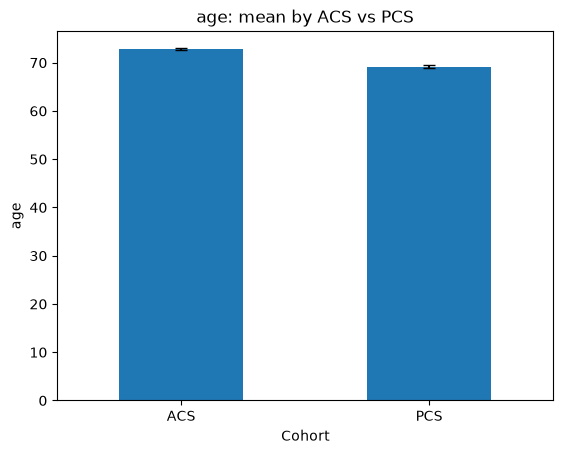

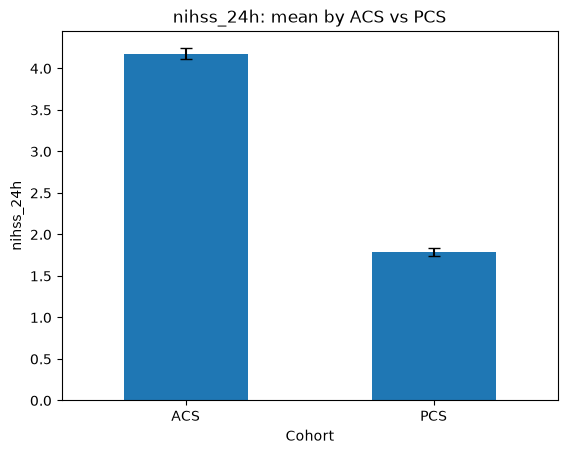

In [8]:
acs_pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=common_filters & F(clinical_sdr).isin(["1", "2"]),
    handle_missing=common_missing,
    outlier_handling=common_outliers,
    new_columns=[stroke_territory_creator],
)

pcs_pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=common_filters & (F(clinical_sdr) == "4"),
    handle_missing=common_missing,
    outlier_handling=common_outliers,
    new_columns=[stroke_territory_creator],
)

acs_numerical_summary = acs_pipeline.describe()
pcs_numerical_summary = pcs_pipeline.describe()

display(Markdown("### Numeric summaries by cohort"))

numeric_df = _numeric_df_from_describe(
    acs_numerical_summary,
    pcs_numerical_summary,
    variables=["age", "nihss_24h", "nihss_adm"],
)

display(
    numeric_df[
        ["cohort", "variable", "num_dtps", "num_na", "missing_rate", "mean", "std", "q2"]
    ].style.format(
        {
            "missing_rate": "{:.1%}",
            "mean": "{:.2f}",
            "std": "{:.2f}",
            "q2": "{:.2f}",
        },
        na_rep="—",
    )
)

display(Markdown("### Mean comparisons with approximate 95% CI"))

for variable, sub in numeric_df.groupby("variable"):
    sub = sub.set_index("cohort").reindex(COHORT_ORDER)

    ax = sub["mean"].plot(
        kind="bar",
        yerr=sub["ci95"],
        capsize=4,
        legend=False,
    )
    ax.set_title(f"{variable}: mean by ACS vs PCS")
    ax.set_xlabel("Cohort")
    ax.set_ylabel(variable)
    plt.xticks(rotation=0)
    plt.show()

## 7. Categorical summaries by cohort

### Categorical summaries by cohort

#### Sex

,cohort,variable_label,level_label,count,percent
0,ACS,Sex,1,11337,56.8%
1,ACS,Sex,2,8615,43.2%
2,PCS,Sex,1,4642,63.1%
3,PCS,Sex,2,2714,36.9%


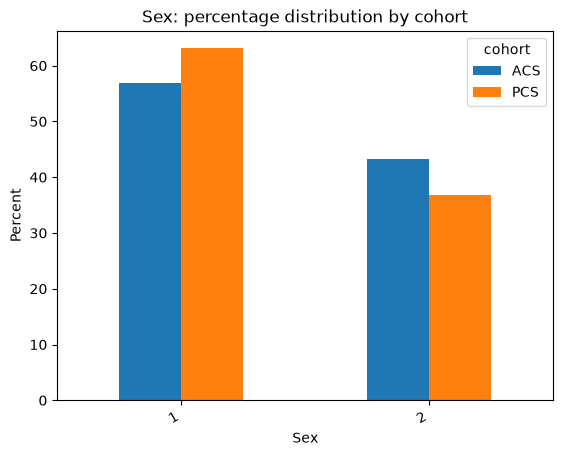

#### IVT

,cohort,variable_label,level_label,count,percent
0,ACS,IVT,0,13407,67.2%
1,ACS,IVT,1,6545,32.8%
2,PCS,IVT,0,6018,81.8%
3,PCS,IVT,1,1338,18.2%


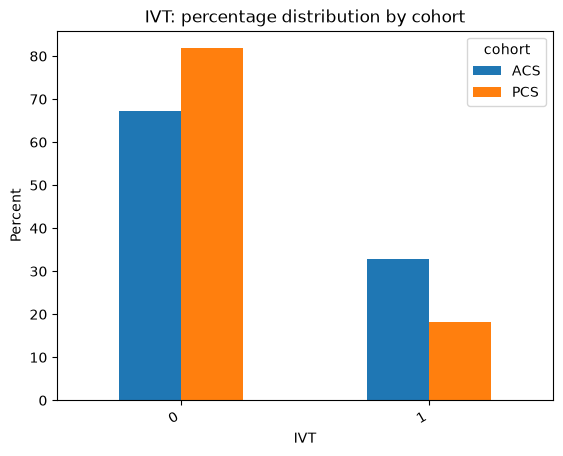

#### EVT

,cohort,variable_label,level_label,count,percent
0,ACS,EVT,0,15397,77.2%
1,ACS,EVT,1,4555,22.8%
2,PCS,EVT,0,6952,94.5%
3,PCS,EVT,1,404,5.5%


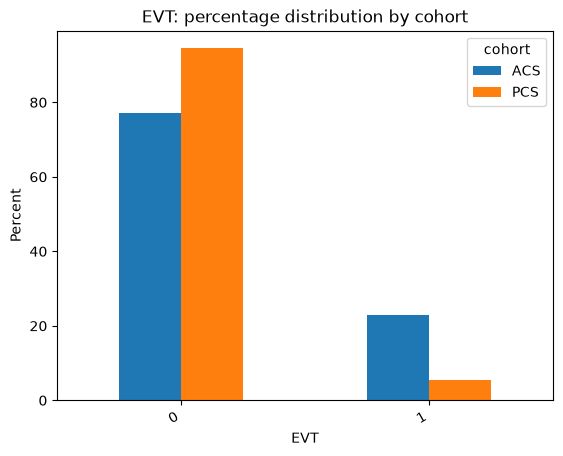

In [9]:
display(Markdown("### Categorical summaries by cohort"))

categorical_variables = [sex, ivt, evt]

for variable in categorical_variables:
    cat_df = _categorical_df_from_describe(
        acs_numerical_summary,
        pcs_numerical_summary,
        variable=variable,
    )

    display(Markdown(f"#### {variable.label}"))

    display(
        cat_df[
            ["cohort", "variable_label", "level_label", "count", "percent"]
        ].style.format(
            {
                "percent": "{:.1f}%",
                "count": "{:.0f}",
            },
            na_rep="—",
        )
    )

    pivot = (
        cat_df.pivot(index="level_label", columns="cohort", values="percent")
        .reindex(columns=COHORT_ORDER)
    )

    ax = pivot.plot(kind="bar")
    ax.set_title(f"{variable.label}: percentage distribution by cohort")
    ax.set_xlabel(variable.label)
    ax.set_ylabel("Percent")
    plt.xticks(rotation=30, ha="right")
    plt.show()

## 8. ACS vs PCS statistical comparison

Independent t-tests, Mann-Whitney U tests, and chi-square tests below cover the cohort comparisons included in this example.

### Chi-square tests (sex, IVT, EVT)

In [ ]:
display(Markdown("### Independent t-tests (ACS vs PCS)"))

age_t_test = pipeline.t_test(
    variable=age,
    group_by=stroke_territory_cohort,
    group_a="ACS",
    group_b="PCS",
)

nihss_24h_t_test = pipeline.t_test(
    variable=nihss_24h,
    group_by=stroke_territory_cohort,
    group_a="ACS",
    group_b="PCS",
)

nihss_adm_t_test = pipeline.t_test(
    variable=nihss_adm,
    group_by=stroke_territory_cohort,
    group_a="ACS",
    group_b="PCS",
)

for label, result in [
    ("Age", age_t_test),
    ("24h NIHSS", nihss_24h_t_test),
    ("Admission NIHSS", nihss_adm_t_test),
]:
    display(Markdown(f"#### {label}"))
    display(result)

ttest_df = _ttest_df_from_results(
    {
        "age": age_t_test,
        "nihss_24h": nihss_24h_t_test,
        "nihss_adm": nihss_adm_t_test,
    }
)

display(
    ttest_df.style.format(
        {
            "t_stat": "{:.2f}",
            "df": "{:.1f}",
            "p_value": "{:.4f}",
            "p": "{:.4f}",
            "mean_diff": "{:.2f}",
            "ci_lower": "{:.2f}",
            "ci_upper": "{:.2f}",
            "cohens_d": "{:.2f}",
        },
        na_rep="—",
    )
)

plot_df = ttest_df.dropna(subset=["mean_diff"]).copy()
if {"ci_lower", "ci_upper"}.issubset(plot_df.columns):
    plot_df = plot_df.dropna(subset=["ci_lower", "ci_upper"])
y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(7, max(2.5, 0.6 * len(plot_df))))
xerr = None
if {"ci_lower", "ci_upper"}.issubset(plot_df.columns):
    xerr = [
        plot_df["mean_diff"] - plot_df["ci_lower"],
        plot_df["ci_upper"] - plot_df["mean_diff"],
    ]
ax.errorbar(
    plot_df["mean_diff"],
    y_pos,
    xerr=xerr,
    fmt="o",
    capsize=4,
)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["variable"])
ax.set_xlabel("Mean difference: ACS - PCS")
ax.set_title("T-test effect estimates with 95% CI")
plt.show()

display(Markdown("### Mann-Whitney U tests (ACS vs PCS)"))

age_mann_whitney = pipeline.mann_whitney_u_test(
    variable=age,
    group_by=stroke_territory_cohort,
    group_a="ACS",
    group_b="PCS",
)

nihss_24h_mann_whitney = pipeline.mann_whitney_u_test(
    variable=nihss_24h,
    group_by=stroke_territory_cohort,
    group_a="ACS",
    group_b="PCS",
)

nihss_adm_mann_whitney = pipeline.mann_whitney_u_test(
    variable=nihss_adm,
    group_by=stroke_territory_cohort,
    group_a="ACS",
    group_b="PCS",
)

mann_whitney_df = _mann_whitney_df_from_results(
    {
        "age": age_mann_whitney,
        "nihss_24h": nihss_24h_mann_whitney,
        "nihss_adm": nihss_adm_mann_whitney,
    }
)

display(
    mann_whitney_df.style.format(
        {
            "u_stat": "{:.2f}",
            "z_score": "{:.2f}",
            "p_value": "{:.4f}",
            "n_acs": "{:.0f}",
            "n_pcs": "{:.0f}",
        },
        na_rep="—",
    )
)


In [ ]:
sex_chi_square = pipeline.chi_square_test(
    x=stroke_territory_cohort,
    y=sex,
)

ivt_chi_square = pipeline.chi_square_test(
    x=stroke_territory_cohort,
    y=ivt,
)

evt_chi_square = pipeline.chi_square_test(
    x=stroke_territory_cohort,
    y=evt,
)

display(Markdown("### Chi-square tests (stroke territory cohort vs treatment/demographics)"))

chi_square_rows = []
for label, result in [
    ("sex", sex_chi_square),
    ("ivt", ivt_chi_square),
    ("evt", evt_chi_square),
]:
    display(Markdown(f"#### {label}"))
    display(result)
    frame = result.to_frame().copy()
    frame.insert(0, "comparison", label)
    chi_square_rows.append(frame)
    result.plot()
    plt.show()

chi_square_df = pd.concat(chi_square_rows, ignore_index=True)
display(
    chi_square_df.style.format(
        {
            "chi2": "{:.2f}",
            "p_value": "{:.4g}",
            "dof": "{:.0f}",
        },
        na_rep="—",
    )
)


## 9. Logistic regression for good 3-month outcome

The target is `fu_3m_mrs_good`, where code `1` means good outcome. The model includes demographics, severity, treatments, and the derived ACS/PCS cohort.

In [12]:
logistic_regression_result = pipeline.logistic_regression(
    x=[
        age,
        nihss_24h,
        nihss_adm,
        sex,
        ivt,
        evt,
        stroke_territory_cohort,
    ],
    y=good_outcome,
    positive_class="1",
)

### Logistic regression: adjusted odds ratios

`ModelResult.to_frame()` supplies coefficients and odds ratios. Term labels below map internal codes to readable ACS/PCS and category labels.


In [ ]:
logreg_payload = logistic_regression_result.summary()
logreg_df = _logistic_result_to_dataframe(logistic_regression_result)

logreg_variables_by_code = {
    internal_code(sex): sex,
    internal_code(ivt): ivt,
    internal_code(evt): evt,
    internal_code(stroke_territory_cohort): stroke_territory_cohort,
    internal_code(age): age,
    internal_code(nihss_24h): nihss_24h,
    internal_code(nihss_adm): nihss_adm,
}

logreg_df["label"] = logreg_df["term"].apply(
    lambda term: _logistic_term_label(term, logreg_variables_by_code)
)
logreg_df["p_value_fmt"] = logreg_df["p_value"].apply(_format_p_value)
logreg_df["or_95_ci"] = logreg_df.apply(
    lambda row: f'{row["odds_ratio"]:.2f} ({row["or_lower_ci"]:.2f}, {row["or_upper_ci"]:.2f})',
    axis=1,
)

display(logistic_regression_result)
display(
    logreg_df[
        ["label", "coef", "odds_ratio", "or_lower_ci", "or_upper_ci", "p_value"]
    ].style.format(
        {
            "coef": "{:.3f}",
            "odds_ratio": "{:.2f}",
            "or_lower_ci": "{:.2f}",
            "or_upper_ci": "{:.2f}",
            "p_value": "{:.4g}",
        },
        na_rep="—",
    )
)


### Adjusted odds-ratio forest plot

Built from the labeled coefficient table. For a quick unlabeled forest plot, `logistic_regression_result.plot()` also works.


In [ ]:
plot_df = logreg_df[logreg_df["term"] != "Intercept"].copy()
plot_df = plot_df.iloc[::-1]

y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9, max(4, 0.55 * len(plot_df))))

xerr = [
    plot_df["odds_ratio"] - plot_df["or_lower_ci"],
    plot_df["or_upper_ci"] - plot_df["odds_ratio"],
]

ax.errorbar(
    plot_df["odds_ratio"],
    y_pos,
    xerr=xerr,
    fmt="o",
    capsize=4,
)

ax.axvline(1, linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Adjusted odds ratio, log scale")
dependent = logreg_payload.get("dependent_var") if isinstance(logreg_payload, dict) else None
ax.set_title(f'Logistic regression for {dependent or good_outcome.label}')

x_text = plot_df["or_upper_ci"].max() * 1.15
for y, (_, row) in zip(y_pos, plot_df.iterrows()):
    ax.text(
        x_text,
        y,
        f'OR {row["odds_ratio"]:.2f} '
        f'({row["or_lower_ci"]:.2f}, {row["or_upper_ci"]:.2f}), '
        f'p={row["p_value_fmt"]}',
        va="center",
        fontsize=9,
    )

ax.set_xlim(
    max(plot_df["or_lower_ci"].min() * 0.75, 0.01),
    x_text * 1.8,
)

plt.tight_layout()
plt.show()


### Logistic regression model fit


In [15]:
model_summary = logreg_payload["summary"]

fit_df = pd.DataFrame(
    {
        "metric": [
            "N observations",
            "df model",
            "df residual",
            "Cox-Snell pseudo R²",
            "McFadden pseudo R²",
            "Log-likelihood null",
            "Log-likelihood model",
            "AIC",
            "BIC",
        ],
        "value": [
            model_summary.get("n_obs"),
            model_summary.get("df_model"),
            model_summary.get("df_resid"),
            model_summary.get("r_squared_cs"),
            model_summary.get("r_squared_mcf"),
            model_summary.get("ll0"),
            model_summary.get("ll"),
            model_summary.get("aic"),
            model_summary.get("bic"),
        ],
    }
)

display(
    fit_df.style.format(
        {"value": "{:.3f}"},
        na_rep="—",
    )
)


,metric,value
0,N observations,27308.000
1,df model,7.000
2,df residual,27300.000
3,Cox-Snell pseudo R²,0.330
4,McFadden pseudo R²,0.333
5,Log-likelihood null,-16452.217
6,Log-likelihood model,-10977.810
7,AIC,21971.621
8,BIC,22037.340


**Interpretation note:**

The forest plot reports adjusted odds ratios from the logistic regression model. Values above 1 indicate higher odds of `fu_3m_mrs_good`; values below 1 indicate lower odds. Confidence intervals crossing 1 indicate that the corresponding adjusted association is not statistically clear at the 95% confidence level.

The intercept is omitted from the plot because it is not clinically interpretable as a covariate effect.


## Statistical scope

This notebook reports aggregate summaries, independent t-tests, chi-square tests, and adjusted logistic regression. Add non-parametric rank tests only when your platform provides an approved implementation for federated execution.